Cell 1 - Import

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

from minicv.io import read_image
from minicv.features import (
    color_histogram_descriptor,
    hu_moments_descriptor,
    hog_descriptor,
    lbp_descriptor
)

Cell 2 — Image picker

In [5]:
def pick_image():
    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    path = filedialog.askopenfilename(
        title="Select an image for transformations",
        filetypes=[("Image files", "*.png *.jpg *.jpeg")]
    )
    root.destroy()
    return path

IMAGE_PATH = pick_image()
img_gray = read_image(IMAGE_PATH, mode="gray")
img_rgb = read_image(IMAGE_PATH, mode="rgb")
print(f"Loaded Image: {img_gray.shape}")

Loaded Image: (588, 1400)


Cell 3 — Global Color Descriptor

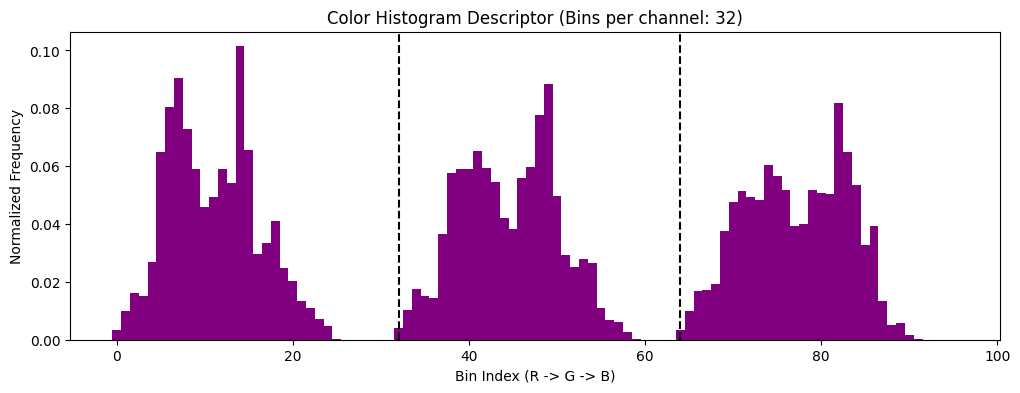

In [7]:
bins_count = 32
color_feat = color_histogram_descriptor(img_rgb, bins=bins_count)

plt.figure(figsize=(12, 4))
plt.bar(range(len(color_feat)), color_feat, color='purple', width=1.0)
plt.title(f"Color Histogram Descriptor (Bins per channel: {bins_count})")
plt.xlabel("Bin Index (R -> G -> B)")
plt.ylabel("Normalized Frequency")

# Draw vertical lines to separate R, G, and B if it's a 3-channel image
if img_rgb.ndim == 3:
    plt.axvline(x=bins_count, color='black', linestyle='--')
    plt.axvline(x=bins_count*2, color='black', linestyle='--')

plt.show()

Cell 4 — Hu Moments (Geometry Descriptor)

--- Hu Moments Descriptor (Log-Transformed) ---
Moment 1:     2.6238
Moment 2:     5.5456
Moment 3:     9.3808
Moment 4:     9.4626
Moment 5:    10.0000
Moment 6:     9.9987
Moment 7:    10.0000


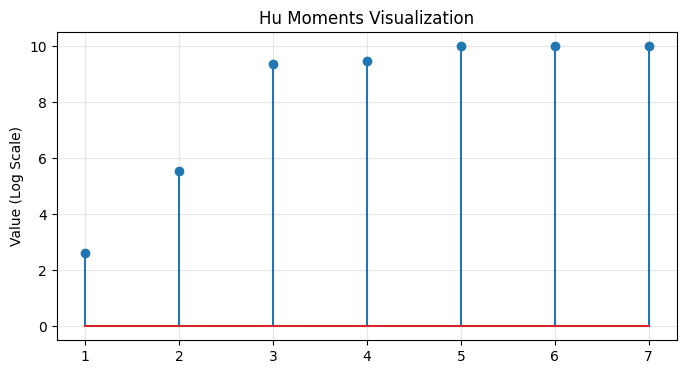

In [8]:
hu_feat = hu_moments_descriptor(img_gray)

print("--- Hu Moments Descriptor (Log-Transformed) ---")
for i, val in enumerate(hu_feat):
    print(f"Moment {i+1}: {val:10.4f}")

plt.figure(figsize=(8, 4))
plt.stem(range(1, 8), hu_feat)
plt.title("Hu Moments Visualization")
plt.xticks(range(1, 8))
plt.ylabel("Value (Log Scale)")
plt.grid(True, alpha=0.3)
plt.show()

Cell 5 — HOG (Local Gradient Descriptor)

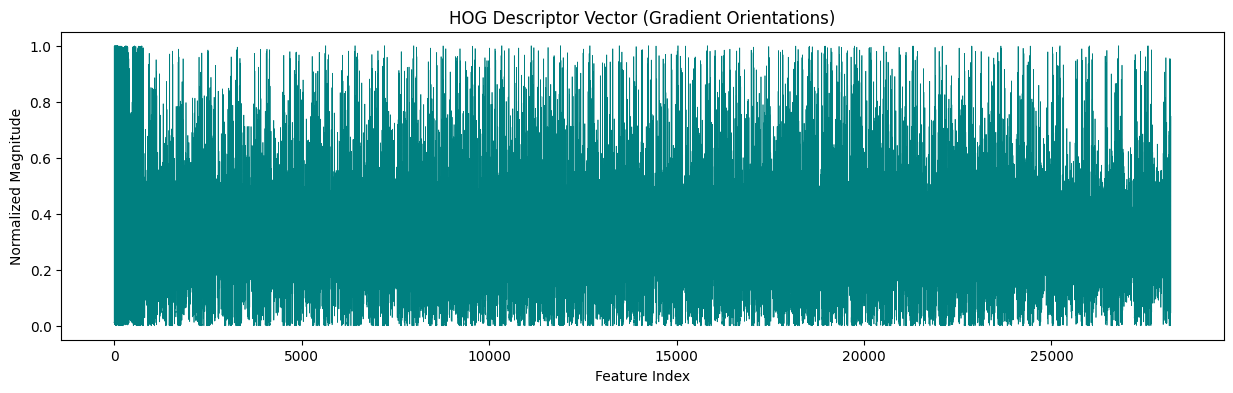

HOG Vector Dimension: 28188


In [9]:
hog_feat = hog_descriptor(img_gray, cell_size=16, bins=9)

plt.figure(figsize=(15, 4))
plt.plot(hog_feat, color='teal', linewidth=0.5)
plt.title("HOG Descriptor Vector (Gradient Orientations)")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Magnitude")
plt.show()

print(f"HOG Vector Dimension: {len(hog_feat)}")

Cell 6 — LBP (Local Texture Descriptor)

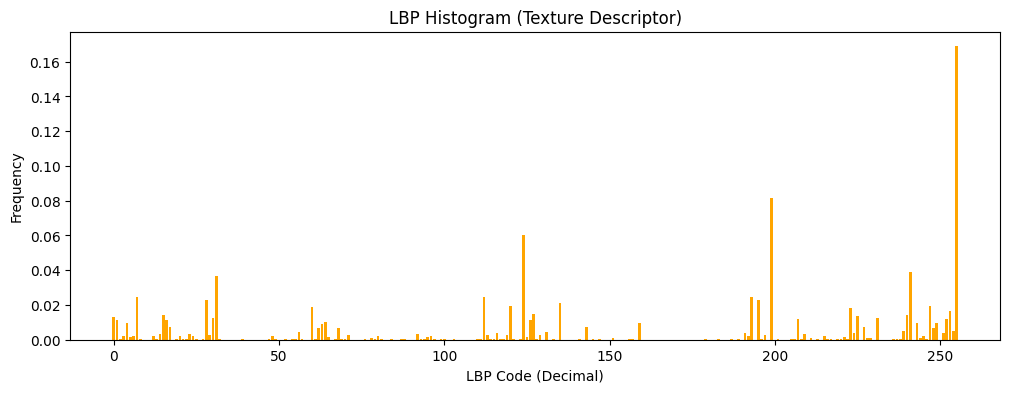

In [10]:
lbp_feat = lbp_descriptor(img_gray, radius=1, n_points=8)

plt.figure(figsize=(12, 4))
plt.bar(range(len(lbp_feat)), lbp_feat, color='orange')
plt.title("LBP Histogram (Texture Descriptor)")
plt.xlabel("LBP Code (Decimal)")
plt.ylabel("Frequency")
plt.show()

Cell 7 — Feature Vector Comparison

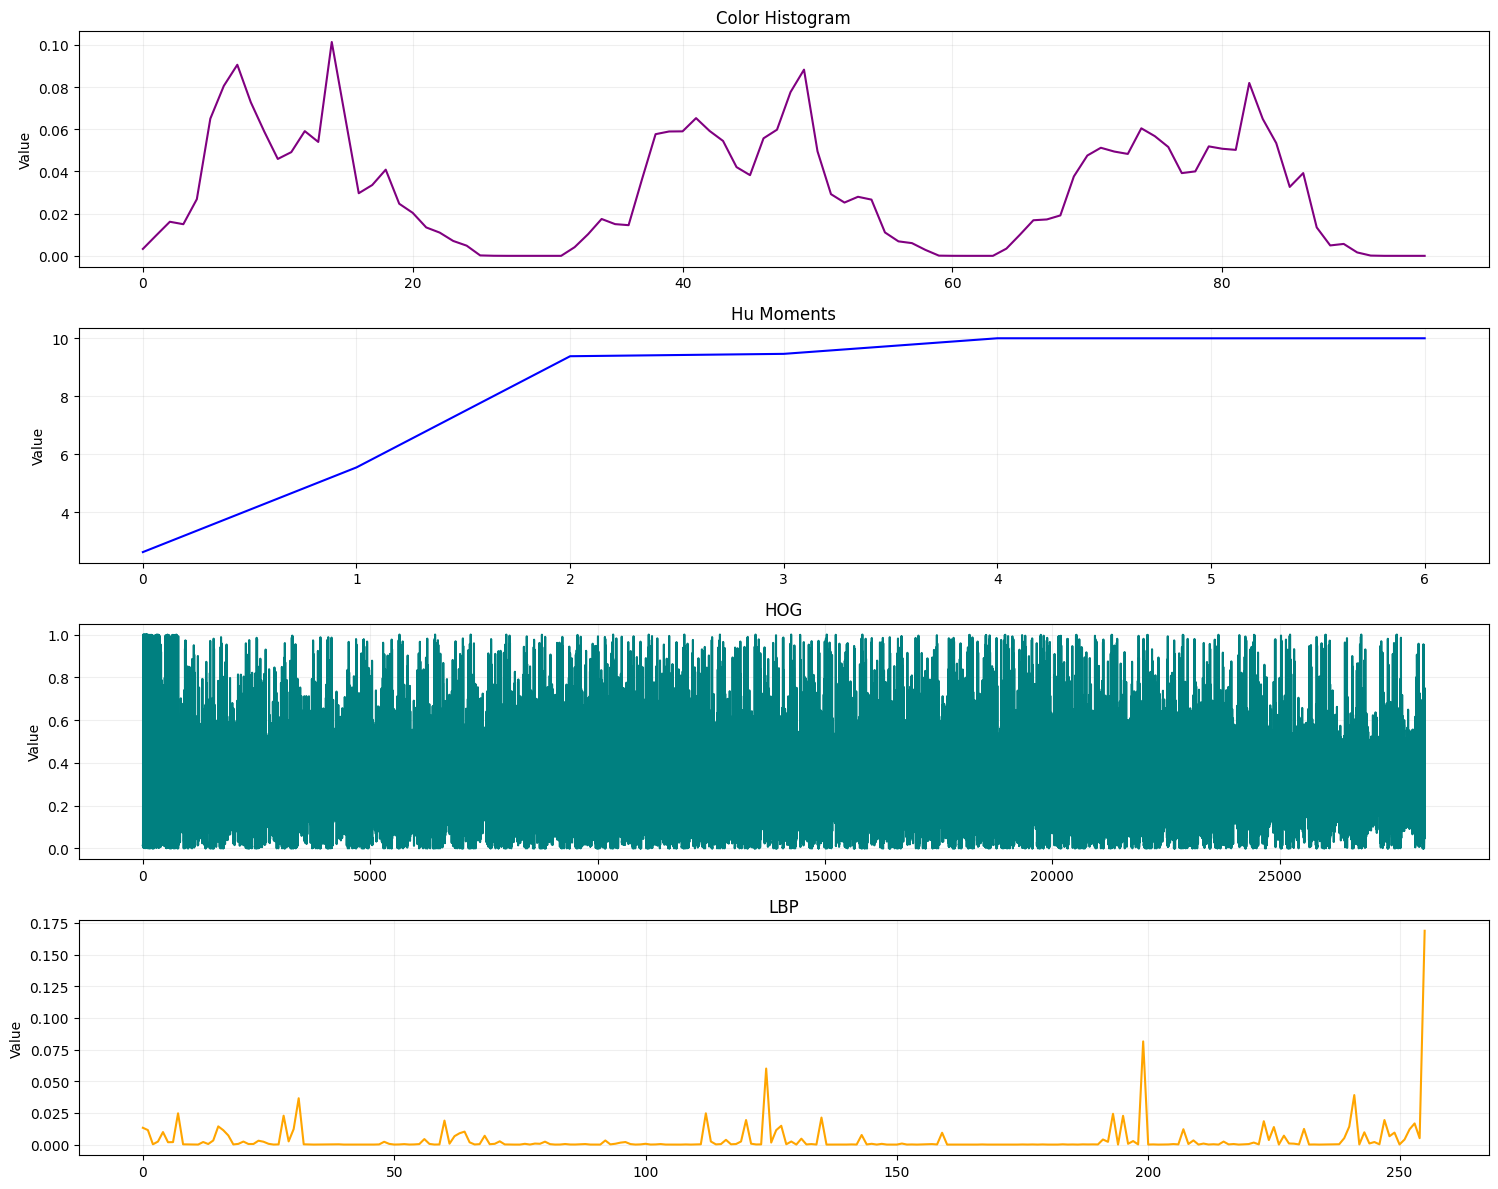

Total Unique Image Fingerprint Size: 28547


In [11]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

descriptors = [color_feat, hu_feat, hog_feat, lbp_feat]
titles = ["Color Histogram", "Hu Moments", "HOG", "LBP"]
colors = ["purple", "blue", "teal", "orange"]

for ax, feat, title, col in zip(axes, descriptors, titles, colors):
    ax.plot(feat, color=col)
    ax.set_title(title)
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Final Fingerprint (Concatenated)
final_fingerprint = np.concatenate(descriptors)
print(f"Total Unique Image Fingerprint Size: {len(final_fingerprint)}")